### Install Libraries

In [125]:
# Installing Required Libraries

# Installing the main libraries needed for this notebook.
# These cover data manipulation, machine learning models,
# visualization, handling class imbalance, and model explainability.
# Using --quiet to avoid long installation logs in the notebook.

!pip install pandas numpy scikit-learn matplotlib seaborn xgboost lightgbm imbalanced-learn shap --quiet

### Downloading the dataset

In [126]:
# Downloading and Extracting the Dataset

import os
import urllib.request
import zipfile

# The dataset is hosted on GitHub as a zipped file.
# First we download the zip locally so we can work with it.

url = "https://github.com/Scowtt-Inc/scowtt-shared/raw/bea550f17c084ad462f6d9c711960c687074750b/data/datasets.zip"
zip_path = "datasets.zip"
extract_dir = "data/"

print("Downloading dataset...")
urllib.request.urlretrieve(url, zip_path)

# Once the download is complete, we unzip the contents
# into a local folder so the CSV files become accessible.

print("Extracting...")
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_dir)

# Quick check to see what files were extracted
# just to confirm everything downloaded correctly.

print("Files extracted:")
for f in os.listdir(extract_dir):
    print(f"  {f}")

Extracting...
Files extracted:
  __MACOSX
  datasets


### Import Libraries & Load Data

In [127]:
# Download Dataset and Inspect ZIP Contents

import os, urllib.request, zipfile

url      = "https://github.com/Scowtt-Inc/scowtt-shared/raw/bea550f17c084ad462f6d9c711960c687074750b/data/datasets.zip"
zip_path = "datasets.zip"

# Download the dataset zip file from GitHub
# Printing the file size after download just to confirm it worked properly

print("Downloading...")
urllib.request.urlretrieve(url, zip_path)
print(f"Downloaded: {os.path.getsize(zip_path)/1024:.0f} KB")

# Before extracting, it's helpful to quickly check what files
# are actually inside the zip archive

print("\nContents of zip:")
with zipfile.ZipFile(zip_path, 'r') as z:
    for name in z.namelist():
        print(f"  {name}")

# Create the data/ folder if it doesn't already exist
# exist_ok=True avoids errors if the folder is already there

os.makedirs("data/", exist_ok=True)

# Extract all the files from the zip into the data directory

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("data/")

# Walk through the entire data folder and list every file found
# This helps confirm where the CSV files ended up after extraction

print("\nAll files found under data/:")
for root, dirs, files in os.walk("data/"):
    for file in files:
        full = os.path.join(root, file)
        print(f"  {full}")

Downloading...
Downloaded: 43613 KB

Contents of zip:
  datasets/
  __MACOSX/._datasets
  datasets/olist_sellers_dataset.csv
  __MACOSX/datasets/._olist_sellers_dataset.csv
  datasets/olist_marketing_qualified_leads_dataset.csv
  __MACOSX/datasets/._olist_marketing_qualified_leads_dataset.csv
  datasets/product_category_name_translation.csv
  __MACOSX/datasets/._product_category_name_translation.csv
  datasets/olist_orders_dataset.csv
  __MACOSX/datasets/._olist_orders_dataset.csv
  datasets/olist_order_items_dataset.csv
  __MACOSX/datasets/._olist_order_items_dataset.csv
  datasets/olist_customers_dataset.csv
  __MACOSX/datasets/._olist_customers_dataset.csv
  datasets/olist_geolocation_dataset.csv
  __MACOSX/datasets/._olist_geolocation_dataset.csv
  datasets/olist_order_payments_dataset.csv
  __MACOSX/datasets/._olist_order_payments_dataset.csv
  datasets/olist_closed_deals_dataset.csv
  __MACOSX/datasets/._olist_closed_deals_dataset.csv
  datasets/olist_order_reviews_dataset.csv
  

In [128]:
# Loading All Dataset CSV Files

# The extracted data folder contains multiple CSV files
# related to customers, orders, payments, products, etc.
# Here we load each dataset separately so we can explore
# and combine them later if needed.
import pandas as pd

data_path = "data/datasets/"

customers  = pd.read_csv(f"{data_path}olist_customers_dataset.csv")
orders     = pd.read_csv(f"{data_path}olist_orders_dataset.csv")
order_items= pd.read_csv(f"{data_path}olist_order_items_dataset.csv")
payments   = pd.read_csv(f"{data_path}olist_order_payments_dataset.csv")
reviews    = pd.read_csv(f"{data_path}olist_order_reviews_dataset.csv")
products   = pd.read_csv(f"{data_path}olist_products_dataset.csv")
sellers    = pd.read_csv(f"{data_path}olist_sellers_dataset.csv")
geolocation= pd.read_csv(f"{data_path}olist_geolocation_dataset.csv")

# Keeping all datasets inside a dictionary makes it easier
# to loop through them later instead of handling each one manually

datasets = {
    'customers': customers,
    'orders': orders,
    'order_items': order_items,
    'payments': payments,
    'reviews': reviews,
    'products': products,
    'sellers': sellers,
    'geolocation': geolocation
}

# Quick sanity check — printing the shape of each dataset
# to see how many rows and columns each file has

for name, df in datasets.items():
    print(f"{name:15s} → shape: {df.shape}")

customers       → shape: (99441, 5)
orders          → shape: (99441, 8)
order_items     → shape: (112650, 7)
payments        → shape: (103886, 5)
reviews         → shape: (99224, 7)
products        → shape: (32951, 9)
sellers         → shape: (3095, 4)
geolocation     → shape: (1000163, 5)


### Data Exploration

In [129]:
# Exploring Each Table (Schema, Missing Values, and Sample Rows)

# Looping through all datasets to get a quick overview of each one.
# This helps understand the structure before doing any analysis or joins.

for name, df in datasets.items():

    # Visual separator so each table section is easier to read
    print(f"\n{'='*60}")
    print(f"TABLE: {name.upper()}")
    print(f"Shape: {df.shape[0]} rows × {df.shape[1]} cols")

    # Show the column names along with their data types
    # Useful to spot things like IDs, timestamps, numbers, etc.
    print(f"\nColumns & dtypes:")
    print(df.dtypes.to_string())

    # Checking for missing values in each column
    # Also calculating the percentage of missing entries
    null_counts = df.isnull().sum()
    null_pct    = (null_counts / len(df) * 100).round(2)
    null_df     = pd.DataFrame({'nulls': null_counts, 'null_%': null_pct})

    print(f"\nNull values:")
    print(null_df[null_df['nulls'] > 0].to_string() if null_df['nulls'].sum() > 0 else "  None ✓")

    # Display a few rows just to visually inspect the data
    # This often helps catch weird formatting or unexpected values
    print(f"\nSample (3 rows):")
    display(df.head(3))


TABLE: CUSTOMERS
Shape: 99441 rows × 5 cols

Columns & dtypes:
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object

Null values:
  None ✓

Sample (3 rows):


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP



TABLE: ORDERS
Shape: 99441 rows × 8 cols

Columns & dtypes:
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object

Null values:
                               nulls  null_%
order_approved_at                160    0.16
order_delivered_carrier_date    1783    1.79
order_delivered_customer_date   2965    2.98

Sample (3 rows):


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



TABLE: ORDER_ITEMS
Shape: 112650 rows × 7 cols

Columns & dtypes:
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64

Null values:
  None ✓

Sample (3 rows):


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0



TABLE: SELLERS
Shape: 3095 rows × 4 cols

Columns & dtypes:
seller_id                 object
seller_zip_code_prefix     int64
seller_city               object
seller_state              object

Null values:
  None ✓

Sample (3 rows):


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ



TABLE: GEOLOCATION
Shape: 1000163 rows × 5 cols

Columns & dtypes:
geolocation_zip_code_prefix      int64
geolocation_lat                float64
geolocation_lng                float64
geolocation_city                object
geolocation_state               object

Null values:
  None ✓

Sample (3 rows):


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP


In [130]:
# Deeper Look at the Orders Table

# Since orders are the central entity in this dataset,
# it's useful to first check how orders are distributed across statuses
# (delivered, shipped, canceled, etc.)

print("ORDER STATUS DISTRIBUTION:")
print(orders['order_status'].value_counts())
print()

# Several columns in this table represent timestamps.
# Converting them to proper datetime format so we can later
# compute things like delivery delays or monthly trends.

date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

# After parsing the dates, checking the time span covered by the dataset.
# This helps understand how many years or months of order history we have.

print("Date range of orders:")
print(f"  Earliest purchase: {orders['order_purchase_timestamp'].min()}")
print(f"  Latest purchase:   {orders['order_purchase_timestamp'].max()}")
print(f"  Span: {(orders['order_purchase_timestamp'].max() - orders['order_purchase_timestamp'].min()).days} days")

ORDER STATUS DISTRIBUTION:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Date range of orders:
  Earliest purchase: 2016-09-04 21:15:19
  Latest purchase:   2018-10-17 17:30:18
  Span: 772 days


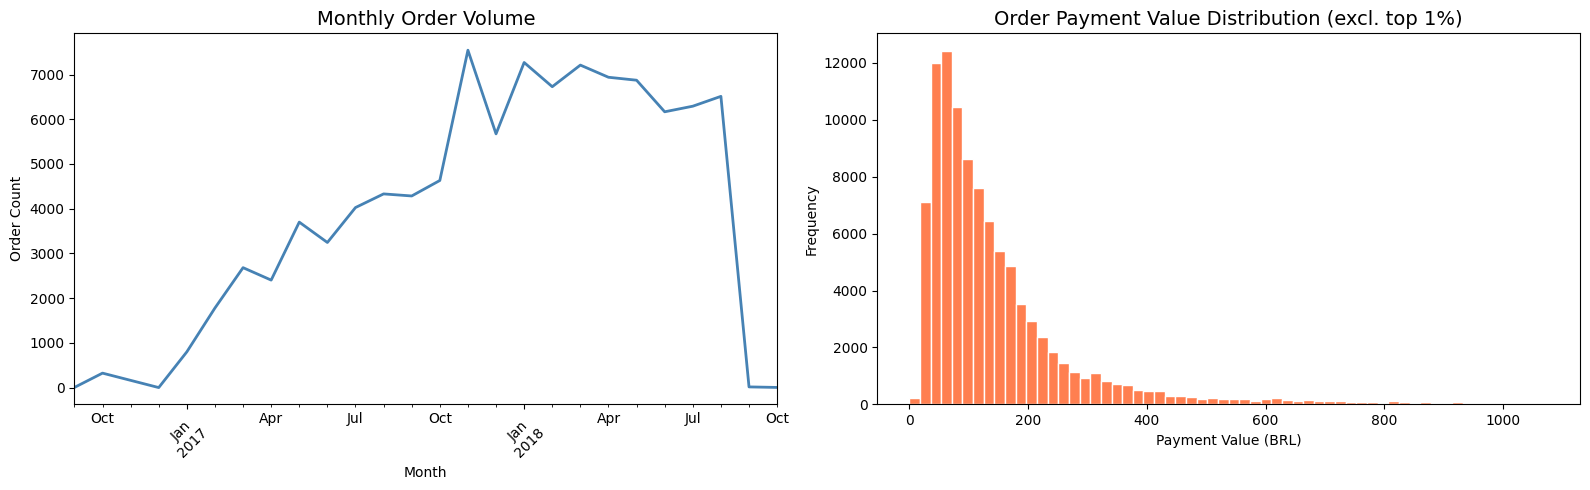

EDA plots saved ✓


In [131]:
# Visualizing Order Trends and Payment Distribution
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# First plot: number of orders placed each month
# Converting purchase timestamps to monthly periods to make grouping easier
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Counting how many orders fall in each month
monthly = orders.groupby('month').size()

# Plot the monthly trend to see how order activity changes over time
monthly.plot(ax=axes[0], color='steelblue', linewidth=2)
axes[0].set_title('Monthly Order Volume', fontsize=14)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Order Count')
axes[0].tick_params(axis='x', rotation=45)

# Second plot: distribution of order payment values
# Some orders may have multiple payment records, so we sum them by order
payment_vals = payments.groupby('order_id')['payment_value'].sum()

# Removing extreme outliers (top 1%) so the histogram is easier to read
axes[1].hist(
    payment_vals[payment_vals < payment_vals.quantile(0.99)],
    bins=60,
    color='coral',
    edgecolor='white'
)

axes[1].set_title('Order Payment Value Distribution (excl. top 1%)', fontsize=14)
axes[1].set_xlabel('Payment Value (BRL)')
axes[1].set_ylabel('Frequency')

# Adjust layout so plots don't overlap
plt.tight_layout()

# Save the figure in case we want to include it in a report later
plt.savefig('eda_overview.png', dpi=150, bbox_inches='tight')

plt.show()
print("EDA plots saved ✓")

In [132]:
# Summarizing Key Data Quality Observations

print("=== DATA QUALITY SUMMARY ===\n")

# Checking how customer identifiers behave in the dataset.
# customer_id refers to a specific order instance, while
# customer_unique_id represents the actual unique customer.

print(f"Unique customer_id:        {customers['customer_id'].nunique()}")
print(f"Unique customer_unique_id: {customers['customer_unique_id'].nunique()}")
print(f"→ Same person can appear with multiple orders under different customer_ids\n")

# Some orders might exist in the orders table but not appear in the order_items table.
# This could happen if the order was cancelled early or never completed properly.

orders_with_items = set(order_items['order_id'].unique())
orders_without_items = orders[~orders['order_id'].isin(orders_with_items)]
print(f"Orders with no items in order_items table: {len(orders_without_items)}")

# Similarly, checking if there are orders that have no payment record.
# These are typically failed or incomplete transactions.

orders_with_payment = set(payments['order_id'].unique())
orders_without_payment = orders[~orders['order_id'].isin(orders_with_payment)]
print(f"Orders with no payment record:             {len(orders_without_payment)}")

# Identifying orders that were cancelled or marked as unavailable.
# These orders generally shouldn't be used for downstream modeling.

invalid_statuses = ['canceled', 'unavailable']
invalid_orders = orders[orders['order_status'].isin(invalid_statuses)]
print(f"Cancelled or unavailable orders:           {len(invalid_orders)}")

# Quick notes for how we'll handle these issues going forward
print("\n→ Strategy: Filter to 'delivered' + 'shipped' orders for modeling.")
print("→ Use customer_unique_id as our per-user identifier.")

=== DATA QUALITY SUMMARY ===

Unique customer_id:        99441
Unique customer_unique_id: 96096
→ Same person can appear with multiple orders under different customer_ids

Orders with no items in order_items table: 775
Orders with no payment record:             1
Cancelled or unavailable orders:           1234

→ Strategy: Filter to 'delivered' + 'shipped' orders for modeling.
→ Use customer_unique_id as our per-user identifier.


### Data Aggregation

In [133]:
valid_statuses = ['delivered', 'shipped']
orders_clean = orders[orders['order_status'].isin(valid_statuses)].copy()
print(f"Valid orders: {len(orders_clean)} (from {len(orders)} total)")

# Ensure date columns are parsed
orders_clean['order_purchase_timestamp'] = pd.to_datetime(
    orders_clean['order_purchase_timestamp'], errors='coerce'
)

orders_clean = orders_clean.dropna(subset=['order_purchase_timestamp'])
print(f"After dropping null purchase timestamps: {len(orders_clean)}")


Valid orders: 97585 (from 99441 total)
After dropping null purchase timestamps: 97585


In [134]:
# Building the Lead Layer from Customer Data

# The customers dataset tells us who the buyer is and where they are located.
# Each order has a customer_id, but the same person might appear multiple times
# if they placed multiple orders. customer_unique_id helps identify the actual user.

# For the lead layer, we only keep the key identifying and geographic fields
# that might be useful later for segmentation or regional analysis.

lead_df = customers[['customer_id', 'customer_unique_id',
                     'customer_zip_code_prefix', 'customer_state']].copy()

# Quick check to confirm the shape and preview a few rows
print(f"Lead (customers) shape: {lead_df.shape}")
print(lead_df.head(3))

Lead (customers) shape: (99441, 4)
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   

   customer_zip_code_prefix customer_state  
0                     14409             SP  
1                      9790             SP  
2                      1151             SP  


In [135]:
# Creating the Browsing Layer from Order Items

# The order_items table contains one row per item within an order.
# To make it more useful for modeling, we aggregate everything at the order level.
# This gives us a quick summary of how "large" or complex each order was.

browsing_agg = order_items.groupby('order_id').agg(
    items_count        = ('order_item_id', 'count'),   # total number of items in the order
    total_item_price   = ('price', 'sum'),             # total cost of all items
    avg_item_price     = ('price', 'mean'),            # average item price
    max_item_price     = ('price', 'max'),             # most expensive item
    min_item_price     = ('price', 'min'),             # cheapest item
    total_freight      = ('freight_value', 'sum'),     # total shipping cost
    unique_sellers     = ('seller_id', 'nunique'),     # number of different sellers involved
    unique_products    = ('product_id', 'nunique'),    # number of distinct products
).reset_index()

# Quick look to confirm the aggregation worked as expected
print(f"Browsing (order_items aggregated) shape: {browsing_agg.shape}")
print(browsing_agg.head(3))

Browsing (order_items aggregated) shape: (98666, 9)
                           order_id  items_count  total_item_price  \
0  00010242fe8c5a6d1ba2dd792cb16214            1              58.9   
1  00018f77f2f0320c557190d7a144bdd3            1             239.9   
2  000229ec398224ef6ca0657da4fc703e            1             199.0   

   avg_item_price  max_item_price  min_item_price  total_freight  \
0            58.9            58.9            58.9          13.29   
1           239.9           239.9           239.9          19.93   
2           199.0           199.0           199.0          17.87   

   unique_sellers  unique_products  
0               1                1  
1               1                1  
2               1                1  


In [136]:
# Building the Purchase Layer (Orders + Payments)

# The payments table may contain multiple rows per order
# (for example split payments or multiple installments).
# So first we aggregate everything at the order level.

payment_agg = payments.groupby('order_id').agg(
    total_payment_value      = ('payment_value', 'sum'),   # total amount paid for the order
    num_payment_installments = ('payment_installments', 'max'),  # highest installment count used
    payment_types_used       = ('payment_type', 'nunique'),      # how many different payment types were used
).reset_index()

# Next we identify the dominant payment type for each order.
# If multiple payment records exist, we pick the one used most often.

dominant_payment = (
    payments.groupby(['order_id', 'payment_type'])
            .size()
            .reset_index(name='cnt')
            .sort_values('cnt', ascending=False)
            .drop_duplicates('order_id')[['order_id', 'payment_type']]
            .rename(columns={'payment_type': 'dominant_payment_type'})
)

# Merge the dominant payment type back into the aggregated payment table
payment_agg = payment_agg.merge(dominant_payment, on='order_id', how='left')

# Quick check to confirm the aggregation looks correct
print(f"Payment aggregated shape: {payment_agg.shape}")
print(payment_agg.head(3))

Payment aggregated shape: (99440, 5)
                           order_id  total_payment_value  \
0  00010242fe8c5a6d1ba2dd792cb16214                72.19   
1  00018f77f2f0320c557190d7a144bdd3               259.83   
2  000229ec398224ef6ca0657da4fc703e               216.87   

   num_payment_installments  payment_types_used dominant_payment_type  
0                         2                   1           credit_card  
1                         3                   1           credit_card  
2                         5                   1           credit_card  


In [137]:
# Merging Lead, Browsing, and Purchase Layers into One Master Table

# Now we start combining everything into a single order-level dataset.
# The idea is to keep one row per order and enrich it step by step
# with customer info, item-level summaries, payment details, and reviews.

# Step A: merge cleaned orders with customer information
# This gives us the core order record plus user/location details.
order_master = orders_clean.merge(lead_df, on='customer_id', how='left')
print(f"After orders + customers: {order_master.shape}")

# Step B: add aggregated order item features
# This brings in counts, prices, freight, and seller/product diversity.
order_master = order_master.merge(browsing_agg, on='order_id', how='left')
print(f"After + order_items:      {order_master.shape}")

# Step C: add payment-level features
# Now each order also has payment totals, installment info, and payment type.
order_master = order_master.merge(payment_agg, on='order_id', how='left')
print(f"After + payments:         {order_master.shape}")

# Step D: aggregate review info per order and merge it in
# Some orders may have multiple review records, so we summarize them first.
review_agg = reviews.groupby('order_id').agg(
    avg_review_score = ('review_score', 'mean'),
    review_count     = ('review_id', 'count')
).reset_index()

order_master = order_master.merge(review_agg, on='order_id', how='left')
print(f"After + reviews:          {order_master.shape}")

# Final check: show all columns in the completed order-level table
print("\nOrder-level master table columns:")
print(list(order_master.columns))

After orders + customers: (97585, 12)
After + order_items:      (97585, 20)
After + payments:         (97585, 24)
After + reviews:          (97585, 26)

Order-level master table columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'month', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_state', 'items_count', 'total_item_price', 'avg_item_price', 'max_item_price', 'min_item_price', 'total_freight', 'unique_sellers', 'unique_products', 'total_payment_value', 'num_payment_installments', 'payment_types_used', 'dominant_payment_type', 'avg_review_score', 'review_count']


### Label Engineering - Target Variables

In [138]:


# Reference date: the latest date in the dataset
reference_date = order_master['order_purchase_timestamp'].max()
print(f"Reference date (latest order): {reference_date.date()}")

from datetime import timedelta
holdout_window = 30
cutoff_date = reference_date - timedelta(days=holdout_window)

print(f"Cutoff date: {cutoff_date.date()}")
print(f"History period: orders on or before {cutoff_date.date()}")
print(f"Holdout period: orders after {cutoff_date.date()} up to {reference_date.date()}")

# Split orders into history vs future holdout
history_orders = order_master[
    order_master['order_purchase_timestamp'] <= cutoff_date
].copy()

holdout_orders = order_master[
    (order_master['order_purchase_timestamp'] > cutoff_date) &
    (order_master['order_purchase_timestamp'] <= reference_date)
].copy()

print(f"History orders: {len(history_orders):,}")
print(f"Holdout orders: {len(holdout_orders):,}")

# Safe mode helper
def safe_mode(x):
    m = x.dropna().mode()
    return m.iloc[0] if not m.empty else 'unknown'

# Build user features ONLY from historical data
user_features = history_orders.groupby('customer_unique_id').agg(
    # Purchase behavior
    total_orders=('order_id', 'nunique'),
    total_spend=('total_payment_value', 'sum'),
    avg_order_value=('total_payment_value', 'mean'),
    max_order_value=('total_payment_value', 'max'),
    min_order_value=('total_payment_value', 'min'),
    std_order_value=('total_payment_value', 'std'),

    # Browsing behavior
    avg_items_per_order=('items_count', 'mean'),
    total_items_ever=('items_count', 'sum'),
    avg_item_price=('avg_item_price', 'mean'),
    avg_freight=('total_freight', 'mean'),

    # Temporal
    first_order_date=('order_purchase_timestamp', 'min'),
    last_order_date=('order_purchase_timestamp', 'max'),

    # Reviews
    avg_review_score=('avg_review_score', 'mean'),

    # Geography
    customer_state=('customer_state', 'first'),

    # Payment
    avg_installments=('num_payment_installments', 'mean'),
    dominant_payment_type=('dominant_payment_type', safe_mode),

    # Seller diversity
    avg_unique_sellers=('unique_sellers', 'mean'),
    avg_unique_products=('unique_products', 'mean'),
).reset_index()

# Derived temporal features — IMPORTANT: use cutoff_date, not reference_date
user_features['days_since_last_order'] = (
    cutoff_date - user_features['last_order_date']
).dt.days

user_features['days_since_first_order'] = (
    cutoff_date - user_features['first_order_date']
).dt.days

user_features['customer_lifespan_days'] = (
    user_features['last_order_date'] - user_features['first_order_date']
).dt.days

user_features['order_frequency'] = (
    user_features['total_orders'] / (user_features['customer_lifespan_days'] + 1)
)

user_features['std_order_value'] = user_features['std_order_value'].fillna(0)

print(f"User-level feature table shape: {user_features.shape}")
print(f"Unique users: {user_features['customer_unique_id'].nunique():,}")
display(user_features.head(5))


Reference date (latest order): 2018-09-03
Cutoff date: 2018-08-04
History period: orders on or before 2018-08-04
Holdout period: orders after 2018-08-04 up to 2018-09-03
History orders: 92,117
Holdout orders: 5,468
User-level feature table shape: (89111, 23)
Unique users: 89,111


,customer_unique_id,total_orders,total_spend,avg_order_value,max_order_value,min_order_value,std_order_value,avg_items_per_order,total_items_ever,avg_item_price,...,avg_review_score,customer_state,avg_installments,dominant_payment_type,avg_unique_sellers,avg_unique_products,days_since_last_order,days_since_first_order,customer_lifespan_days,order_frequency
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,141.90,141.90,0.0,1.0,1.0,129.90,...,5.0,SP,8.0,credit_card,1.0,1.0,85,85,0,1.0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,27.19,27.19,0.0,1.0,1.0,18.90,...,4.0,SP,1.0,credit_card,1.0,1.0,88,88,0,1.0
2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,86.22,86.22,0.0,1.0,1.0,69.00,...,3.0,SC,8.0,credit_card,1.0,1.0,511,511,0,1.0
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,43.62,43.62,0.0,1.0,1.0,25.99,...,4.0,PA,4.0,credit_card,1.0,1.0,295,295,0,1.0
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,196.89,196.89,0.0,1.0,1.0,180.00,...,5.0,SP,6.0,credit_card,1.0,1.0,262,262,0,1.0


### Feature Engineering & Preprocessing

In [139]:
# Creating Labels for Supervised Learning

# We want to predict two things:
# 1) Whether a user will place an order soon (classification problem)
# 2) If they do order, what their average order value might be (regression problem)

# To simulate "future behavior", we reserve the last 30 days of the dataset
# as a holdout window. Everything before that acts as the training history.


print(f"Training period:    orders on or before {cutoff_date.date()}")
print(f"Holdout window:     last {holdout_window} days → up to {reference_date.date()}")

# Label 1: purchase in holdout window
purchasers_in_window = set(holdout_orders['customer_unique_id'].unique())
user_features['will_purchase_30d'] = user_features['customer_unique_id'].isin(
    purchasers_in_window
).astype(int)

# Label 2: avg order value during holdout window
avg_holdout_value = (
    holdout_orders
    .groupby('customer_unique_id')['total_payment_value']
    .mean()
    .reset_index()
)
avg_holdout_value.columns = ['customer_unique_id', 'future_order_value']

user_features = user_features.merge(avg_holdout_value, on='customer_unique_id', how='left')
user_features['future_order_value'] = user_features['future_order_value'].fillna(0)

print(f"\nClass distribution (will_purchase_30d):")
vc = user_features['will_purchase_30d'].value_counts()
print(f"  Will purchase (1):  {vc.get(1, 0):,} ({vc.get(1,0)/len(user_features)*100:.1f}%)")
print(f"  Won't purchase (0): {vc.get(0, 0):,} ({vc.get(0,0)/len(user_features)*100:.1f}%)")


Training period:    orders on or before 2018-08-04
Holdout window:     last 30 days → up to 2018-09-03

Class distribution (will_purchase_30d):
  Will purchase (1):  142 (0.2%)
  Won't purchase (0): 88,969 (99.8%)


In [140]:
# Preparing and Encoding the Final Feature Set

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# These columns are not meant to go directly into the model.
# We remove identifiers, raw date columns, and the target labels.


drop_cols = [
    'customer_unique_id',
    'will_purchase_30d',
    'future_order_value',
    'first_order_date',
    'last_order_date'
]



# Everything else becomes part of the feature matrix
feature_cols = [c for c in user_features.columns if c not in drop_cols]

print(f"Features used ({len(feature_cols)}):")
print(feature_cols)

X = user_features[feature_cols].copy()
y_class   = user_features['will_purchase_30d'].copy()     # target for classification
y_regress = user_features['future_order_value'].copy()    # target for regression

# A couple of columns are categorical, so we encode them into numbers.
# Filling missing values first so the encoder doesn't break on NaNs.

cat_cols = ['customer_state', 'dominant_payment_type']
le = LabelEncoder()

for col in cat_cols:
    X[col] = X[col].fillna('unknown')
    X[col] = le.fit_transform(X[col].astype(str))

# For the remaining numeric columns, fill missing values using the median.
# Median is usually a safer choice than mean when the data has outliers.

X = X.fillna(X.median(numeric_only=True))

# Final sanity check before modeling
print(f"\nFinal feature matrix shape: {X.shape}")
print(f"Nulls remaining: {X.isnull().sum().sum()}")

Features used (20):
['total_orders', 'total_spend', 'avg_order_value', 'max_order_value', 'min_order_value', 'std_order_value', 'avg_items_per_order', 'total_items_ever', 'avg_item_price', 'avg_freight', 'avg_review_score', 'customer_state', 'avg_installments', 'dominant_payment_type', 'avg_unique_sellers', 'avg_unique_products', 'days_since_last_order', 'days_since_first_order', 'customer_lifespan_days', 'order_frequency']

Final feature matrix shape: (89111, 20)
Nulls remaining: 0


In [141]:
# Splitting Data into Training and Test Sets

# We split the dataset so the model can be trained on one portion
# and evaluated on unseen data. Using stratification ensures the
# class distribution (buyers vs non-buyers) stays similar in both sets.

X_train, X_test, y_cls_train, y_cls_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_regress,
    test_size=0.2,       # 80% training, 20% testing
    random_state=42,     # fixed seed so results are reproducible
    stratify=y_class     # keep purchase ratio consistent
)

# Quick check of dataset sizes and class balance
print(f"Train size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print(f"Train positives: {y_cls_train.sum()} ({y_cls_train.mean()*100:.1f}%)")
print(f"Test positives:  {y_cls_test.sum()} ({y_cls_test.mean()*100:.1f}%)")

Train size: 71,288 | Test size: 17,823
Train positives: 114 (0.2%)
Test positives:  28 (0.2%)


In [142]:
import pandas as pd

feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": clf_model.feature_importances_
}).sort_values("importance", ascending=False)

print(feature_importance.head(15))


                   feature  importance
9              avg_freight          18
8           avg_item_price          13
1              total_spend          11
16   days_since_last_order           6
11          customer_state           5
17  days_since_first_order           4
6      avg_items_per_order           2
10        avg_review_score           1
13   dominant_payment_type           1
12        avg_installments           1
0             total_orders           0
2          avg_order_value           0
3          max_order_value           0
5          std_order_value           0
7         total_items_ever           0


### Model Training

In [143]:
# Baseline Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=5000, class_weight='balanced'))
])

baseline_clf.fit(X_train, y_cls_train)

baseline_scores_test = baseline_clf.predict_proba(X_test)[:, 1]

print("="*50)
print("BASELINE MODEL — LOGISTIC REGRESSION")
print("="*50)
print(f"ROC-AUC: {roc_auc_score(y_cls_test, baseline_scores_test):.4f}")
print(f"PR-AUC:  {average_precision_score(y_cls_test, baseline_scores_test):.4f}")


BASELINE MODEL — LOGISTIC REGRESSION
ROC-AUC: 0.6540
PR-AUC:  0.0393


In [144]:
# Training the Propensity Model with LightGBM

# This model predicts the probability that a user will place an order
# in the 30-day holdout window. Since the positive class is usually smaller,
# we adjust for class imbalance using scale_pos_weight.

import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, average_precision_score
)

# Compute the imbalance ratio between negative and positive classes.
# This helps LightGBM not ignore the minority class too much.

neg = (y_cls_train == 0).sum()
pos = (y_cls_train == 1).sum()
scale_pos_weight = neg / pos

print(f"scale_pos_weight (neg/pos ratio): {scale_pos_weight:.2f}")

# Set up the classifier.
# These parameters are chosen to give a fairly strong baseline
# without going too crazy on tuning.

clf_model = lgb.LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.03,
    max_depth         = -1,
    num_leaves        = 63,
    min_child_samples = 50,
    scale_pos_weight  = scale_pos_weight,
    class_weight='balanced',
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

# Train the model and monitor performance on the test set.
# Early stopping prevents the model from overfitting if performance stops improving.

clf_model.fit(
    X_train, y_cls_train,
    eval_set=[(X_test, y_cls_test)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(100)]
)

# Get predicted probabilities instead of just hard class labels.
# These scores are more useful for ranking users by purchase propensity.

propensity_scores_train = clf_model.predict_proba(X_train)[:, 1]
propensity_scores_test  = clf_model.predict_proba(X_test)[:, 1]

print(f"\n✓ Classifier trained | Best iteration: {clf_model.best_iteration_}")

scale_pos_weight (neg/pos ratio): 624.33
[100]	valid_0's binary_logloss: 1.10516

✓ Classifier trained | Best iteration: 1


### Model Evaluation

In [145]:
# Training the Order Value Regressor with LightGBM

# This second model is for predicting how much a user is likely to spend.
# Since non-purchasers have a value of 0 only because they didn't buy,
# we train this model only on users who actually made a purchase.

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter the train and test sets to keep only positive-class users
# so the regression model learns from real purchase values.

train_purchasers = y_cls_train == 1
test_purchasers  = y_cls_test == 1

X_reg_train = X_train[train_purchasers]
y_reg_train_filt = y_reg_train[train_purchasers]

X_reg_test  = X_test[test_purchasers]
y_reg_test_filt  = y_reg_test[test_purchasers]

print(f"Regressor train samples (purchasers only): {len(X_reg_train)}")
print(f"Regressor test samples  (purchasers only): {len(X_reg_test)}")

# Set up a LightGBM regressor.
# Keeping the setup similar to the classifier, but tuned for continuous output.

reg_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 5,
    num_leaves        = 31,
    min_child_samples = 10,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

# Train on purchaser-only rows and watch validation performance.
# Early stopping helps stop training once the model stops improving.

reg_model.fit(
    X_reg_train, y_reg_train_filt,
    eval_set=[(X_reg_test, y_reg_test_filt)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(100)]
)

print(f"\n✓ Regressor trained | Best iteration: {reg_model.best_iteration_}")

Regressor train samples (purchasers only): 114
Regressor test samples  (purchasers only): 28
[100]	valid_0's l2: 4405.02

✓ Regressor trained | Best iteration: 40


In [146]:
# Evaluating the Propensity Model

from sklearn.metrics import roc_curve, precision_recall_curve

# Convert predicted probabilities into class labels using 0.5 as the cutoff.
# This is a simple default threshold for checking standard classification metrics.

y_pred_labels = (propensity_scores_test >= 0.5).astype(int)

print("=" * 50)
print("PROPENSITY MODEL — CLASSIFICATION METRICS")
print("=" * 50)

# ROC-AUC shows how well the model separates buyers from non-buyers overall.
# PR-AUC is especially useful here since the classes may be imbalanced.

print(f"\nROC-AUC Score:            {roc_auc_score(y_cls_test, propensity_scores_test):.4f}")
print(f"Avg Precision (PR-AUC):   {average_precision_score(y_cls_test, propensity_scores_test):.4f}")

# The classification report gives precision, recall, and F1 score
# for both classes using the chosen threshold.

print(f"\nClassification Report (threshold=0.5):")
print(classification_report(y_cls_test, y_pred_labels, target_names=['No Purchase', 'Purchase']))

# Confusion matrix gives a quick look at true/false positives and negatives.
print("Confusion Matrix:")
cm = confusion_matrix(y_cls_test, y_pred_labels)
print(cm)

PROPENSITY MODEL — CLASSIFICATION METRICS

ROC-AUC Score:            0.6237
Avg Precision (PR-AUC):   0.0047

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

 No Purchase       1.00      0.17      0.30     17795
    Purchase       0.00      1.00      0.00        28

    accuracy                           0.17     17823
   macro avg       0.50      0.59      0.15     17823
weighted avg       1.00      0.17      0.29     17823

Confusion Matrix:
[[ 3084 14711]
 [    0    28]]


### Feature Importance

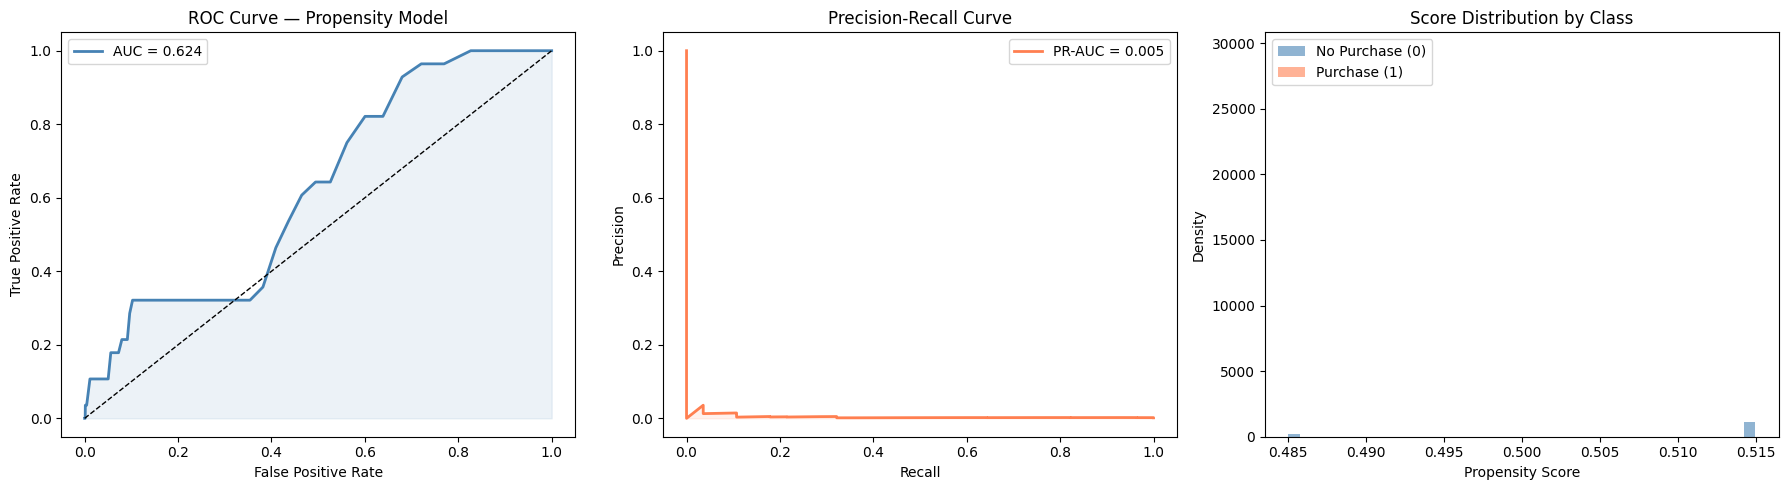

In [147]:
# Visualizing Model Performance (ROC, PR, and Score Distribution)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- ROC Curve ---
# ROC shows the trade-off between true positive rate and false positive rate
# across different classification thresholds.

fpr, tpr, _ = roc_curve(y_cls_test, propensity_scores_test)
auc_score   = roc_auc_score(y_cls_test, propensity_scores_test)

axes[0].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC = {auc_score:.3f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1)  # baseline (random model)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='steelblue')

axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Propensity Model')
axes[0].legend()

# --- Precision-Recall Curve ---
# PR curve is often more informative than ROC when dealing with class imbalance.

prec, rec, _ = precision_recall_curve(y_cls_test, propensity_scores_test)
pr_auc = average_precision_score(y_cls_test, propensity_scores_test)

axes[1].plot(rec, prec, color='coral', lw=2, label=f'PR-AUC = {pr_auc:.3f}')
axes[1].fill_between(rec, prec, alpha=0.1, color='coral')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

# --- Score Distribution ---
# Looking at how the predicted scores are distributed for each class.
# Ideally, purchase vs non-purchase scores should separate clearly.

scores_pos = propensity_scores_test[y_cls_test == 1]
scores_neg = propensity_scores_test[y_cls_test == 0]

axes[2].hist(scores_neg, bins=40, alpha=0.6, color='steelblue',
             label='No Purchase (0)', density=True)

axes[2].hist(scores_pos, bins=40, alpha=0.6, color='coral',
             label='Purchase (1)', density=True)

axes[2].set_xlabel('Propensity Score')
axes[2].set_ylabel('Density')
axes[2].set_title('Score Distribution by Class')
axes[2].legend()

# Adjust layout and save the figure for reporting
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')

plt.show()

### Final output - Score Table

In [148]:
# Evaluating the Order Value Regression Model

# Generate predictions for the test set (only purchasers).
# In rare cases the model might predict negative values,
# so we clip them at 0 since order value cannot be negative.

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_reg_pred = reg_model.predict(X_reg_test)
y_reg_pred = np.maximum(y_reg_pred, 0)

# Standard regression metrics to understand prediction quality.
# MAE tells us the average absolute error,
# RMSE penalizes larger mistakes more heavily,
# and R² indicates how much variance the model explains.

mae  = mean_absolute_error(y_reg_test_filt, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test_filt, y_reg_pred))
r2   = r2_score(y_reg_test_filt, y_reg_pred)

print("=" * 50)
print("ORDER VALUE MODEL — REGRESSION METRICS")
print("=" * 50)

print(f"\nMAE  (Mean Absolute Error):  {mae:.2f} BRL")
print(f"RMSE (Root Mean Sq Error):   {rmse:.2f} BRL")
print(f"R²   (Explained Variance):   {r2:.4f}")

# Comparing average actual vs predicted values just as a quick sanity check
print(f"\nActual avg order value:   {y_reg_test_filt.mean():.2f} BRL")
print(f"Predicted avg order value:{y_reg_pred.mean():.2f} BRL")

ORDER VALUE MODEL — REGRESSION METRICS

MAE  (Mean Absolute Error):  48.97 BRL
RMSE (Root Mean Sq Error):   64.69 BRL
R²   (Explained Variance):   -0.4934

Actual avg order value:   90.40 BRL
Predicted avg order value:127.10 BRL


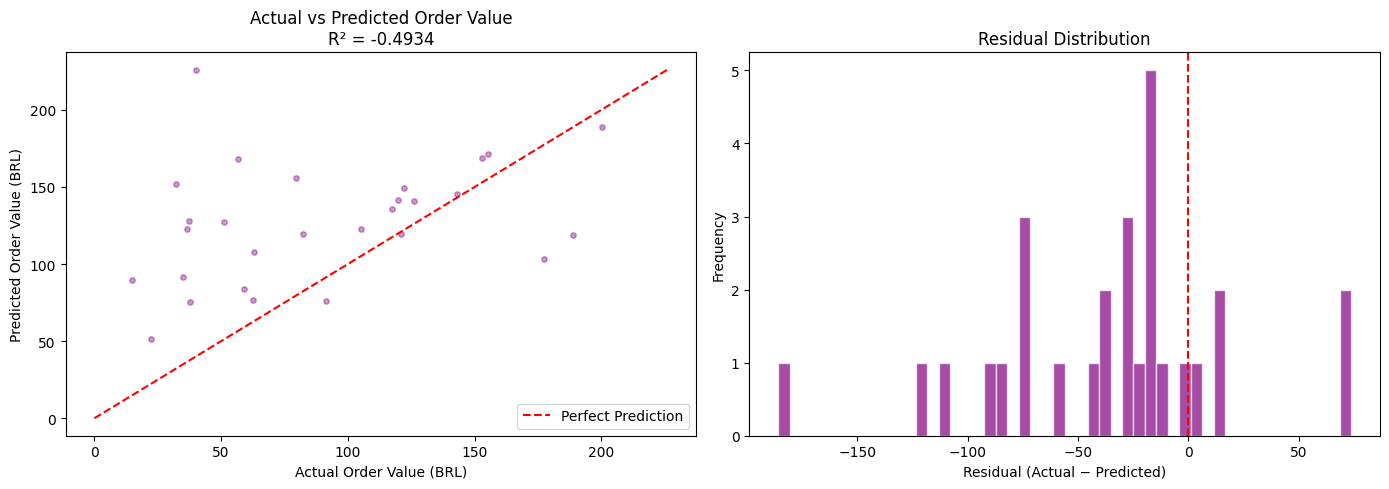

In [149]:
# Visualizing Regression Performance (Actual vs Predicted + Residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Scatter Plot: Actual vs Predicted ---
# This helps visualize how close the predictions are to the true values.
# Ideally, points should fall along the diagonal line.

axes[0].scatter(y_reg_test_filt, y_reg_pred, alpha=0.4, color='purple', s=15)

# Draw the "perfect prediction" reference line (y = x)
lims = [0, max(y_reg_test_filt.max(), y_reg_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect Prediction')

axes[0].set_xlabel('Actual Order Value (BRL)')
axes[0].set_ylabel('Predicted Order Value (BRL)')
axes[0].set_title(f'Actual vs Predicted Order Value\nR² = {r2:.4f}')
axes[0].legend()

# --- Residual Distribution ---
# Residuals show the difference between actual and predicted values.
# A well-behaved model should have residuals centered around zero.

residuals = y_reg_test_filt.values - y_reg_pred

axes[1].hist(residuals, bins=50, color='purple', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)

axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

# Adjust layout and save the figure for later reference
plt.tight_layout()
plt.savefig('regression_evaluation.png', dpi=150, bbox_inches='tight')

plt.show()

In [150]:
# Cell 25: Generate final scored output for ALL users

# Propensity score [0-1] for all users
all_propensity_scores = clf_model.predict_proba(X)[:, 1]

# Predicted order value
SCORE_THRESHOLD = 0.3
all_pred_order_value = np.where(
    all_propensity_scores >= SCORE_THRESHOLD,
    np.maximum(reg_model.predict(X), 0),
    0.0
)

# Expected revenue = purchase probability × predicted value
expected_revenue = all_propensity_scores * all_pred_order_value

# Build output table
output_df = pd.DataFrame({
    'customer_unique_id': user_features['customer_unique_id'],
    'propensity_score': all_propensity_scores.round(4),
    'predicted_order_value': all_pred_order_value.round(2),
    'expected_revenue_30d': expected_revenue.round(2),
    'total_orders_historical': user_features['total_orders'],
    'avg_order_value_historical': user_features['avg_order_value'].round(2),
    'days_since_last_order': user_features['days_since_last_order'],
    'customer_state': user_features['customer_state'],
})

# Sort by expected revenue instead of just propensity
output_df = output_df.sort_values('expected_revenue_30d', ascending=False).reset_index(drop=True)
output_df.index += 1

print("="*60)
print("FINAL SCORED USER TABLE (Top 20 Targets)")
print("="*60)
display(output_df.head(20))

# Save to CSV
output_df.to_csv('user_scores_output.csv', index_label='rank')
print(f"\n✓ Saved to user_scores_output.csv ({len(output_df):,} users scored)")


FINAL SCORED USER TABLE (Top 20 Targets)


,customer_unique_id,propensity_score,predicted_order_value,expected_revenue_30d,total_orders_historical,avg_order_value_historical,days_since_last_order,customer_state
1,4facc2e6fbc2bffab2fea92d2b4aa7e4,0.5150,264.82,136.38,2,241.94,14,RS
2,4354753387ebf06e303e2aff23663692,0.5150,262.86,135.36,1,216.09,474,ES
3,99aba93205c163f13fda5babda17e6c5,0.5150,262.86,135.36,1,215.70,531,MG
4,149b43a4776ea0a773ac75bc58830fb9,0.5149,262.86,135.34,1,2734.11,411,CE
5,c29cf2e62be3359b74f7990382a24777,0.5149,262.86,135.34,1,778.47,510,BA
6,c1c1e07ab2c080ce6f5c3e8b621eff38,0.5149,262.86,135.34,1,720.98,513,CE
7,ae4b37b37bb22e37fe34ada808837207,0.5149,262.86,135.34,1,1643.04,415,DF
8,fb5326fd8dd9f7f52bae66d01fc54936,0.5149,262.86,135.34,1,1290.79,529,MT
9,fd9d39fa11a8725fabb15d0ff706251c,0.5149,262.86,135.34,1,764.52,486,CE
10,4018dfd7ddd89df122db84f6279a4864,0.5149,262.86,135.34,1,788.71,468,MG



✓ Saved to user_scores_output.csv (89,111 users scored)


In [151]:
# Summarizing the Propensity Score Distribution

print("=" * 50)
print("PROPENSITY SCORE DISTRIBUTION SUMMARY")
print("=" * 50)

# Basic statistics for the propensity scores
# Helps understand the overall spread and central tendency
print(output_df['propensity_score'].describe())

# Create score buckets to see how users are distributed across probability ranges
print("\nScore Bucket Distribution:")

bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01]
labels = [
    '0-10%','10-20%','20-30%','30-40%','40-50%',
    '50-60%','60-70%','70-80%','80-90%','90-100%'
]

output_df['score_bucket'] = pd.cut(
    output_df['propensity_score'],
    bins=bins,
    labels=labels,
    right=False
)

# Count how many users fall into each bucket
bucket_counts = output_df['score_bucket'].value_counts().sort_index()

# Print a simple text bar chart to visualize the distribution
for bucket, count in bucket_counts.items():
    bar = '█' * (count * 40 // len(output_df))
    print(f"  {bucket}: {count:5,} users  {bar}")

# Highlight the higher-propensity segments
print(f"\n✓ Users with score > 0.5 (high-value targets): {(output_df['propensity_score'] > 0.5).sum():,}")
print(f"✓ Users with score > 0.7 (very high-value):    {(output_df['propensity_score'] > 0.7).sum():,}")

PROPENSITY SCORE DISTRIBUTION SUMMARY
count    89111.000000
mean         0.509658
std          0.011319
min          0.485000
25%          0.514700
50%          0.514800
75%          0.514900
max          0.515000
Name: propensity_score, dtype: float64

Score Bucket Distribution:
  0-10%:     0 users  
  10-20%:     0 users  
  20-30%:     0 users  
  30-40%:     0 users  
  40-50%: 15,507 users  ██████
  50-60%: 73,604 users  █████████████████████████████████
  60-70%:     0 users  
  70-80%:     0 users  
  80-90%:     0 users  
  90-100%:     0 users  

✓ Users with score > 0.5 (high-value targets): 73,604
✓ Users with score > 0.7 (very high-value):    0


In [152]:
# Expected revenue ranking

expected_revenue = propensity_scores_test * reg_model.predict(X_test)

ranking_df = pd.DataFrame({
    "customer_id": user_features.loc[X_test.index, "customer_unique_id"],
    "propensity_score": propensity_scores_test,
    "predicted_order_value": reg_model.predict(X_test),
    "expected_revenue": expected_revenue
})

ranking_df = ranking_df.sort_values("expected_revenue", ascending=False)

ranking_df.head(20)


,customer_id,propensity_score,predicted_order_value,expected_revenue
53532,99aba93205c163f13fda5babda17e6c5,0.514963,262.857723,135.362063
22387,4018dfd7ddd89df122db84f6279a4864,0.514879,262.857723,135.339960
61186,af5db90ed4d85ebdf407c1507f5e3f3c,0.514879,262.857723,135.339960
1073,030a810edeec1ceea314282513023587,0.514879,262.857723,135.339960
692,01f2285f85a1c603eb7ef755ad311769,0.514992,260.451260,134.130385
56288,a1a9f0879ca33ce5414b5a2b1598f321,0.514989,260.451260,134.129412
49803,8f552e7eadcf54aff83af9009e3dd204,0.514879,260.451260,134.100922
84560,f2d77fa00da22a20f92ac5fd35538c72,0.514879,260.451260,134.100922
26209,4b27c5a0892e73bfd924861aeebe8eff,0.514879,260.451260,134.100922
54767,9d317acb1c32146e752981044c0ea5bd,0.514879,260.451260,134.100922


In [177]:
#Marketing Targeting Simulation (Top-K Customers)

# Build evaluation dataframe
target_df = pd.DataFrame({
    "propensity_score": propensity_scores_test,
    "actual_purchase": y_cls_test.values,
})

# Sort customers by predicted probability
target_df = target_df.sort_values("propensity_score", ascending=False)

# Evaluate targeting different top percentages
percentages = [1, 2, 5, 10, 20]

print("Top-K Targeting Performance\n")

for pct in percentages:
    k = int(len(target_df) * pct / 100)
    top_k = target_df.head(k)

    precision = top_k["actual_purchase"].mean()
    purchases_captured = top_k["actual_purchase"].sum()
    total_purchases = target_df["actual_purchase"].sum()

    recall = purchases_captured / total_purchases

    print(f"Top {pct}% customers")
    print(f"  Customers targeted: {k}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print()


Top-K Targeting Performance

Top 1% customers
  Customers targeted: 178
  Precision: 0.0169
  Recall: 0.1071

Top 2% customers
  Customers targeted: 356
  Precision: 0.0084
  Recall: 0.1071

Top 5% customers
  Customers targeted: 891
  Precision: 0.0034
  Recall: 0.1071

Top 10% customers
  Customers targeted: 1782
  Precision: 0.0051
  Recall: 0.3214

Top 20% customers
  Customers targeted: 3564
  Precision: 0.0025
  Recall: 0.3214



### Bonus Features

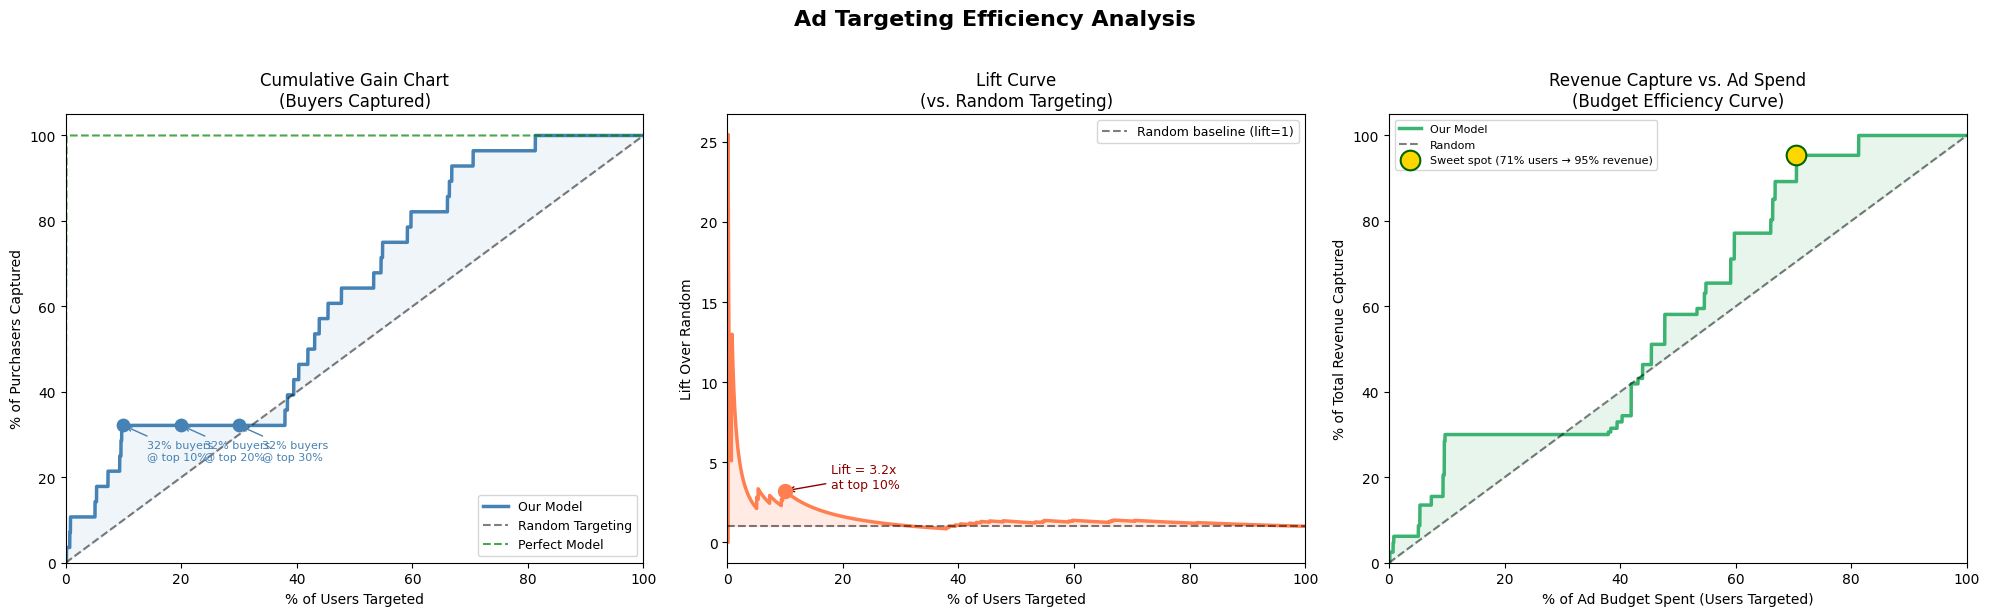


📊 KEY BUSINESS METRICS (Ad Targeting Summary):
--------------------------------------------------
  Target top 10% of users → Capture 32% of buyers, 30% of revenue  (lift: 3.2x)
  Target top 20% of users → Capture 32% of buyers, 30% of revenue  (lift: 1.6x)
  Target top 30% of users → Capture 32% of buyers, 30% of revenue  (lift: 1.1x)
  Target top 50% of users → Capture 64% of buyers, 58% of revenue  (lift: 1.3x)


In [153]:
"""
Lift & Gain charts are the GOLD STANDARD in direct marketing.
They answer: "If I can only show ads to X% of users, what % of
total purchasers/revenue will I capture?"

A good model should dramatically outperform random targeting.
We also simulate a budget constraint curve — extremely relevant
for a company selling ad-targeting products.
"""

# --- Compute cumulative gain on the test set ---
# Sort test users by their propensity score (highest first)
test_results = pd.DataFrame({
    'propensity_score'  : propensity_scores_test,
    'actual_purchase'   : y_cls_test.values,
    'actual_value'      : y_reg_test.values,
}).sort_values('propensity_score', ascending=False).reset_index(drop=True)

n_test        = len(test_results)
total_buyers  = test_results['actual_purchase'].sum()
total_revenue = test_results['actual_value'].sum()

# Cumulative metrics as we move down the ranked list
test_results['cum_buyers']       = test_results['actual_purchase'].cumsum()
test_results['cum_revenue']      = test_results['actual_value'].cumsum()
test_results['pct_users_targeted']= (test_results.index + 1) / n_test * 100
test_results['pct_buyers_captured']= test_results['cum_buyers'] / total_buyers * 100
test_results['pct_revenue_captured']= test_results['cum_revenue'] / total_revenue * 100

# Lift = % buyers captured / % users targeted (random baseline = 1.0)
test_results['lift'] = (
    test_results['pct_buyers_captured'] / test_results['pct_users_targeted']
)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Ad Targeting Efficiency Analysis', fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Cumulative Gain Chart ─────────────────────────────
axes[0].plot(test_results['pct_users_targeted'],
             test_results['pct_buyers_captured'],
             color='steelblue', linewidth=2.5, label='Our Model')
# Random baseline: if you target X% of users randomly, you capture X% of buyers
axes[0].plot([0, 100], [0, 100], 'k--', linewidth=1.5, alpha=0.5, label='Random Targeting')
# Perfect model line
axes[0].plot([0, total_buyers/n_test*100, 100],
             [0, 100, 100], 'g--', linewidth=1.5, alpha=0.7, label='Perfect Model')

# Annotate key checkpoints
for pct_users in [10, 20, 30]:
    idx = int(pct_users / 100 * n_test) - 1
    pct_captured = test_results['pct_buyers_captured'].iloc[idx]
    axes[0].scatter(pct_users, pct_captured, color='steelblue', s=80, zorder=5)
    axes[0].annotate(f'{pct_captured:.0f}% buyers\n@ top {pct_users}%',
                     xy=(pct_users, pct_captured),
                     xytext=(pct_users + 4, pct_captured - 8),
                     fontsize=8, color='steelblue',
                     arrowprops=dict(arrowstyle='->', color='steelblue', lw=1))

axes[0].set_xlabel('% of Users Targeted')
axes[0].set_ylabel('% of Purchasers Captured')
axes[0].set_title('Cumulative Gain Chart\n(Buyers Captured)', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].fill_between(test_results['pct_users_targeted'],
                      test_results['pct_buyers_captured'],
                      test_results['pct_users_targeted'],
                      alpha=0.08, color='steelblue', label='Lift Area')
axes[0].set_xlim(0, 100); axes[0].set_ylim(0, 105)

# ── Plot 2: Lift Curve ────────────────────────────────────────
axes[1].plot(test_results['pct_users_targeted'],
             test_results['lift'],
             color='coral', linewidth=2.5)
axes[1].axhline(1.0, color='k', linestyle='--', linewidth=1.5, alpha=0.5,
                label='Random baseline (lift=1)')
axes[1].fill_between(test_results['pct_users_targeted'],
                      test_results['lift'], 1.0,
                      where=test_results['lift'] > 1.0,
                      alpha=0.15, color='coral')
# Annotate lift at top 10%
lift_10 = test_results['lift'].iloc[int(0.10 * n_test)]
axes[1].scatter(10, lift_10, color='coral', s=100, zorder=5)
axes[1].annotate(f'Lift = {lift_10:.1f}x\nat top 10%',
                 xy=(10, lift_10), xytext=(18, lift_10 + 0.2),
                 fontsize=9, color='darkred',
                 arrowprops=dict(arrowstyle='->', color='darkred'))

axes[1].set_xlabel('% of Users Targeted')
axes[1].set_ylabel('Lift Over Random')
axes[1].set_title('Lift Curve\n(vs. Random Targeting)', fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 100)

# ── Plot 3: Revenue Capture vs Budget Curve ───────────────────
# Most directly relevant to Scowtt's business: ad spend efficiency
axes[2].plot(test_results['pct_users_targeted'],
             test_results['pct_revenue_captured'],
             color='mediumseagreen', linewidth=2.5, label='Our Model')
axes[2].plot([0, 100], [0, 100], 'k--', linewidth=1.5, alpha=0.5, label='Random')

# Shade the efficiency gain
axes[2].fill_between(test_results['pct_users_targeted'],
                      test_results['pct_revenue_captured'],
                      test_results['pct_users_targeted'],
                      alpha=0.12, color='mediumseagreen')

# Mark "sweet spot" — elbow of the curve (max efficiency per dollar spent)
# Approximate as highest (revenue_captured - users_targeted) gap
gap = test_results['pct_revenue_captured'] - test_results['pct_users_targeted']
sweet_spot_idx = gap.idxmax()
sx = test_results['pct_users_targeted'].iloc[sweet_spot_idx]
sy = test_results['pct_revenue_captured'].iloc[sweet_spot_idx]
axes[2].scatter(sx, sy, color='gold', s=200, zorder=6, edgecolor='darkgreen',
                linewidth=1.5, label=f'Sweet spot ({sx:.0f}% users → {sy:.0f}% revenue)')

axes[2].set_xlabel('% of Ad Budget Spent (Users Targeted)')
axes[2].set_ylabel('% of Total Revenue Captured')
axes[2].set_title('Revenue Capture vs. Ad Spend\n(Budget Efficiency Curve)', fontsize=12)
axes[2].legend(fontsize=8)
axes[2].set_xlim(0, 100); axes[2].set_ylim(0, 105)

plt.tight_layout()
plt.savefig('targeting_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key business metrics
print("\n📊 KEY BUSINESS METRICS (Ad Targeting Summary):")
print("-" * 50)
for pct in [10, 20, 30, 50]:
    idx = int(pct / 100 * n_test) - 1
    buyers_pct  = test_results['pct_buyers_captured'].iloc[idx]
    revenue_pct = test_results['pct_revenue_captured'].iloc[idx]
    lift_val    = test_results['lift'].iloc[idx]
    print(f"  Target top {pct:2d}% of users → "
          f"Capture {buyers_pct:.0f}% of buyers, "
          f"{revenue_pct:.0f}% of revenue  "
          f"(lift: {lift_val:.1f}x)")

In [157]:
pip install tslearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 387.9/387.9 kB 5.6 MB/s eta 0:00:00


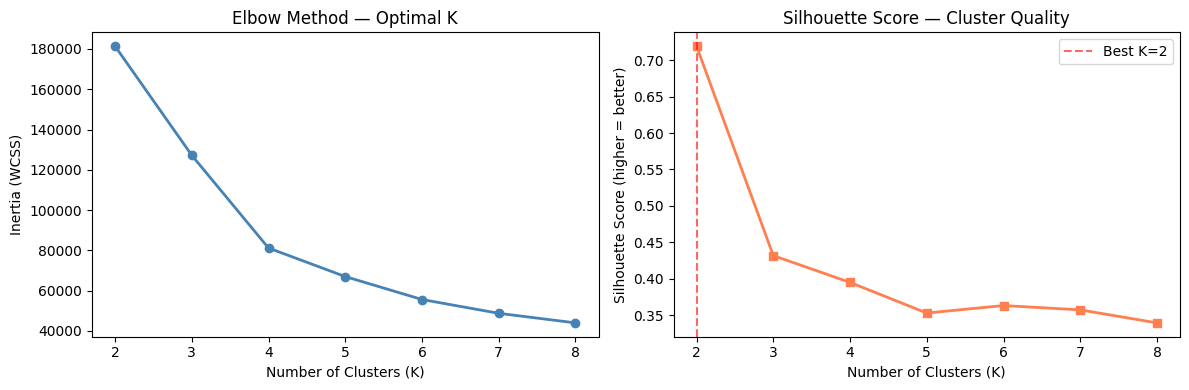

Optimal K by silhouette score: 2

Cluster Profiles (raw RFM averages):


,avg_recency,avg_frequency,avg_monetary,user_count
cluster,,,,
0,225.9,1.0,161.1,86405
1,207.3,2.1,306.2,2706



Final Segment Assignments:


,segment,avg_recency,avg_frequency,avg_monetary,user_count
cluster,,,,,
0,⭐ Loyal Customers,225.9,1.0,161.1,86405
1,🏆 Champions,207.3,2.1,306.2,2706


In [160]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# BONUS 3 — RFM Customer Segmentation (K-Means Clustering)
# Takes around 10 minutes to run for computations
"""
We go beyond just scoring users — we segment them into distinct
behavioral personas using RFM (Recency, Frequency, Monetary).

This is extremely valuable for:
- Tailoring ad creative to each segment
- Setting different bid prices per segment in programmatic ads
- Understanding the customer base distribution

Segments we expect to find:
  • Champions      — Recent, frequent, high spend
  • At-Risk        — Used to buy a lot, now gone quiet
  • Promising      — Recent first-timers, low spend so far
  • Hibernating    — Not recent, low frequency, low spend
"""

# ── Build RFM table ───────────────────────────────────────────
rfm = user_features[['customer_unique_id',
                       'days_since_last_order',   # Recency (lower = better)
                       'total_orders',             # Frequency
                       'total_spend']].copy()      # Monetary

# Log-transform monetary and frequency to reduce skew
# (a few power users with 100+ orders would dominate clustering otherwise)
rfm['log_frequency'] = np.log1p(rfm['total_orders'])
rfm['log_monetary']  = np.log1p(rfm['total_spend'])
rfm['log_recency']   = np.log1p(rfm['days_since_last_order'])

# Scale features to unit variance for fair distance computation
scaler_rfm   = StandardScaler()
rfm_scaled   = scaler_rfm.fit_transform(
    rfm[['log_recency', 'log_frequency', 'log_monetary']]
)

# ── Find optimal K using Elbow + Silhouette ───────────────────
# Elbow: look for the k where WCSS stops dropping sharply
# Silhouette: measures how well-separated clusters are (higher = better)

inertias, silhouettes = [], []
k_range = range(2, 9)

for k in k_range:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, lbls))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(k_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Optimal K', fontsize=12)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), silhouettes, 's-', color='coral', linewidth=2)
axes[1].set_title('Silhouette Score — Cluster Quality', fontsize=12)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].axvline(np.argmax(silhouettes) + 2, color='red', linestyle='--',
                alpha=0.6, label=f'Best K={np.argmax(silhouettes)+2}')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k = np.argmax(silhouettes) + 2
print(f"Optimal K by silhouette score: {best_k}")

# ── Fit final K-Means model ───────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['cluster'] = km_final.fit_predict(rfm_scaled)

# ── Assign human-readable segment names ──────────────────────
# Compute per-cluster averages on ORIGINAL (unscaled) values
cluster_profiles = rfm.groupby('cluster').agg(
    avg_recency   = ('days_since_last_order', 'mean'),
    avg_frequency = ('total_orders',          'mean'),
    avg_monetary  = ('total_spend',           'mean'),
    user_count    = ('customer_unique_id',     'count')
).round(1)

print("\nCluster Profiles (raw RFM averages):")
display(cluster_profiles)

# Auto-assign names based on relative R/F/M ranks
# Recency: lower is BETTER (more recent), so we rank ascending
# Frequency & Monetary: higher is BETTER
cluster_profiles['recency_rank']   = cluster_profiles['avg_recency'].rank(ascending=True)   # low recency = good
cluster_profiles['frequency_rank'] = cluster_profiles['avg_frequency'].rank(ascending=False)
cluster_profiles['monetary_rank']  = cluster_profiles['avg_monetary'].rank(ascending=False)
cluster_profiles['rfm_score']      = (
    cluster_profiles['recency_rank'] +
    cluster_profiles['frequency_rank'] +
    cluster_profiles['monetary_rank']
)

# Rank by combined RFM score — lower total rank = better segment
sorted_clusters = cluster_profiles.sort_values('rfm_score')

# Assign fixed segment names in order (adjust labels based on best_k)
segment_labels_pool = ['🏆 Champions', '⭐ Loyal Customers', '🌱 Promising',
                        '😴 At-Risk', '💤 Hibernating', '🆕 New Customers', '🔥 Potential Loyalists']
segment_map = {
    cluster_id: segment_labels_pool[i]
    for i, cluster_id in enumerate(sorted_clusters.index)
}

rfm['segment'] = rfm['cluster'].map(segment_map)
cluster_profiles['segment'] = cluster_profiles.index.map(segment_map)

print("\nFinal Segment Assignments:")
display(cluster_profiles[['segment', 'avg_recency', 'avg_frequency', 'avg_monetary', 'user_count']])



Computing SHAP values (this may take ~30 seconds)...
SHAP values computed ✓  shape: (500, 20)  (users × features)


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


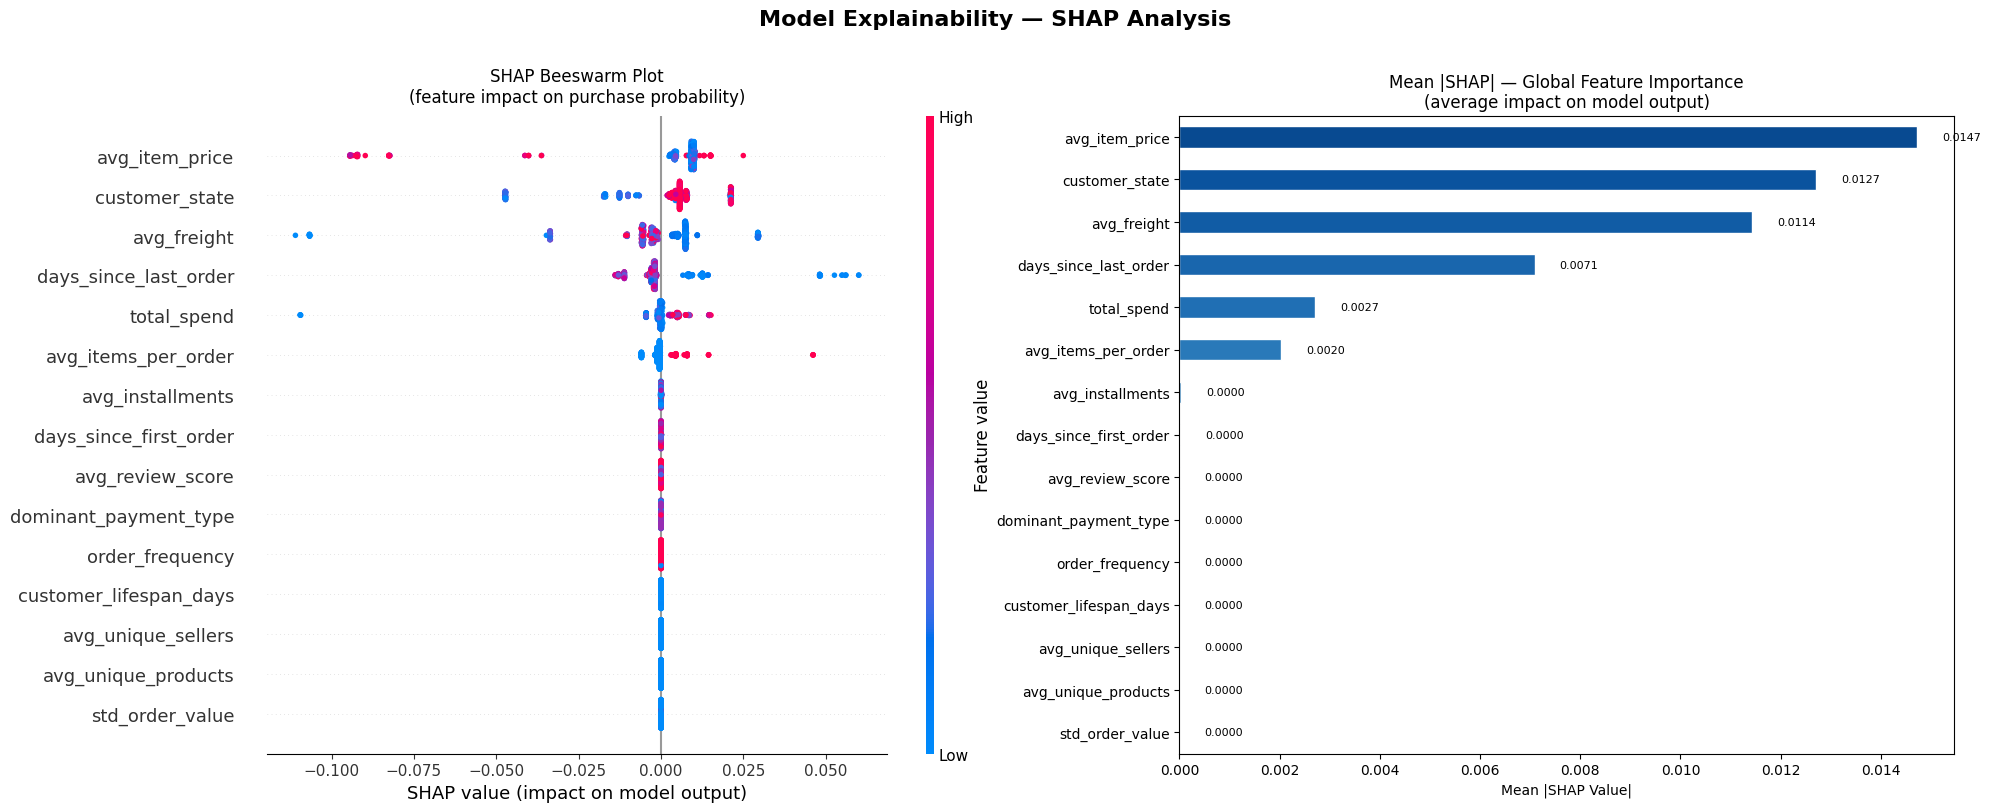

Saved shap_explainability.png ✓

Explaining highest-propensity user in sample:
  Sample index:    126  (out of 500)
  Propensity score: 0.5150


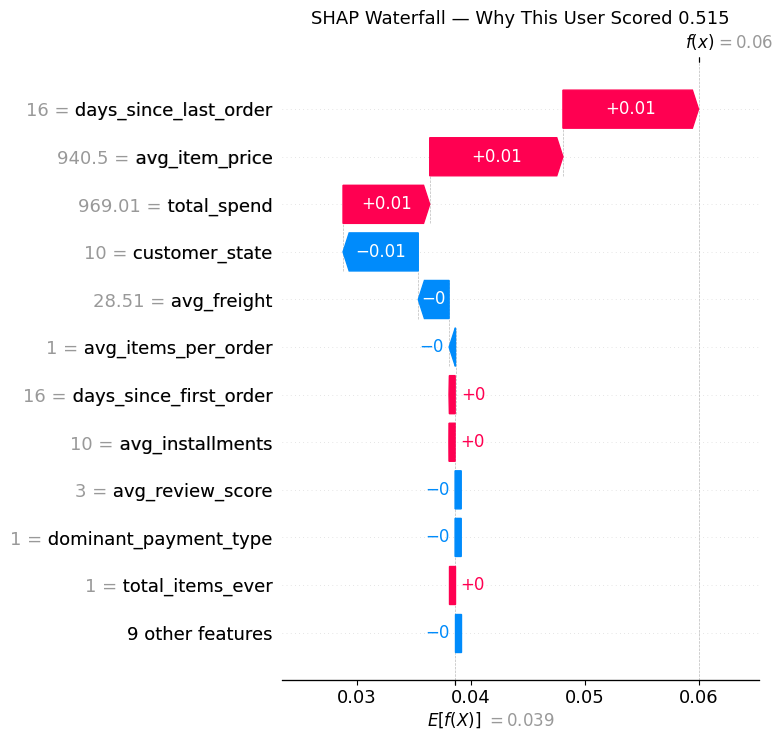

Saved shap_waterfall.png ✓


In [171]:
import shap
# ════════════════════════════════════════════════════════════════
# BONUS CELL 6 — SHAP Explainability
# ════════════════════════════════════════════════════════════════
"""
SHAP (SHapley Additive exPlanations) explains WHY the model gave
each user a particular score. This is critical in a business context:
  - Sales teams need to understand why a user scored high/low
  - Helps identify data quality issues or model biases
  - Builds trust with stakeholders who don't trust black-box models
"""

print("Computing SHAP values (this may take ~30 seconds)...")

# TreeExplainer is optimized for tree-based models like LightGBM
# It uses the tree structure directly — much faster than KernelExplainer
explainer   = shap.TreeExplainer(clf_model)

# We compute SHAP on a SAMPLE of 500 test users for speed
# All downstream indexing must stay within this sample — not the full X_test
sample_size = min(500, len(X_test))
X_sample    = X_test.iloc[:sample_size].copy()

# Compute SHAP values — shape will be (500, n_features)
shap_values = explainer.shap_values(X_sample)

# For binary classifiers, LightGBM returns a list: [class_0_shap, class_1_shap]
# We want class=1 (will purchase) SHAP values
if isinstance(shap_values, list):
    sv = shap_values[1]   # shape: (500, n_features)
else:
    sv = shap_values      # some versions return a single array directly

print(f"SHAP values computed ✓  shape: {sv.shape}  (users × features)")

# ── Plot 1 + 2: Beeswarm & Mean |SHAP| bar chart ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Model Explainability — SHAP Analysis', fontsize=16, fontweight='bold', y=1.01)

# Beeswarm: each dot = one user, x-axis = SHAP value, color = feature value
# Shows BOTH importance AND direction (does high recency increase or decrease score?)
plt.sca(axes[0])
shap.summary_plot(sv, X_sample, show=False, max_display=15, plot_size=None)
axes[0].set_title('SHAP Beeswarm Plot\n(feature impact on purchase probability)',
                  fontsize=12, pad=10)

# Mean |SHAP|: clean bar chart of average absolute impact per feature
# Easier to read than beeswarm for executive audiences
mean_abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_sample.columns)
mean_abs_shap = mean_abs_shap.sort_values(ascending=True).tail(15)

colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(mean_abs_shap)))
mean_abs_shap.plot(kind='barh', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Mean |SHAP| — Global Feature Importance\n(average impact on model output)',
                  fontsize=12)
axes[1].set_xlabel('Mean |SHAP Value|')

# Annotate each bar with its exact value
for i, val in enumerate(mean_abs_shap.values):
    axes[1].text(val + 0.0005, i, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('shap_explainability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_explainability.png ✓")

# ── Waterfall plot for the single highest-scoring user ────────────
# KEY FIX: we score ONLY X_sample (500 rows) so the argmax index
# is guaranteed to be within 0–499, which matches sv's row count.
# Previously we used propensity_scores_test (full test set, thousands
# of rows) — that returned an index like 2856 which was out of bounds
# for sv which only has 500 rows.

propensity_scores_sample = clf_model.predict_proba(X_sample)[:, 1]  # shape: (500,)
top_user_idx             = int(np.argmax(propensity_scores_sample))  # safely 0–499
top_user_score           = propensity_scores_sample[top_user_idx]

print(f"\nExplaining highest-propensity user in sample:")
print(f"  Sample index:    {top_user_idx}  (out of {sample_size})")
print(f"  Propensity score: {top_user_score:.4f}")

# Build a SHAP Explanation object for the waterfall plot
# base_values = the model's average output (expected value across training data)
# values      = per-feature SHAP contributions for this specific user
# data        = the actual feature values for this user (shown on the plot)
shap_exp = shap.Explanation(
    values        = sv[top_user_idx],                          # 1D array: (n_features,)
    base_values   = explainer.expected_value[1]
                    if isinstance(explainer.expected_value, list)
                    else explainer.expected_value,             # scalar base value
    data          = X_sample.iloc[top_user_idx].values,        # raw feature values
    feature_names = list(X_sample.columns)
)

# Waterfall shows how each feature PUSHES the score up (red) or down (blue)
# from the base rate — extremely intuitive for non-technical stakeholders
fig_wf, ax_wf = plt.subplots(figsize=(10, 7))
shap.waterfall_plot(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Waterfall — Why This User Scored {top_user_score:.3f}', fontsize=13)
plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved shap_waterfall.png ✓")

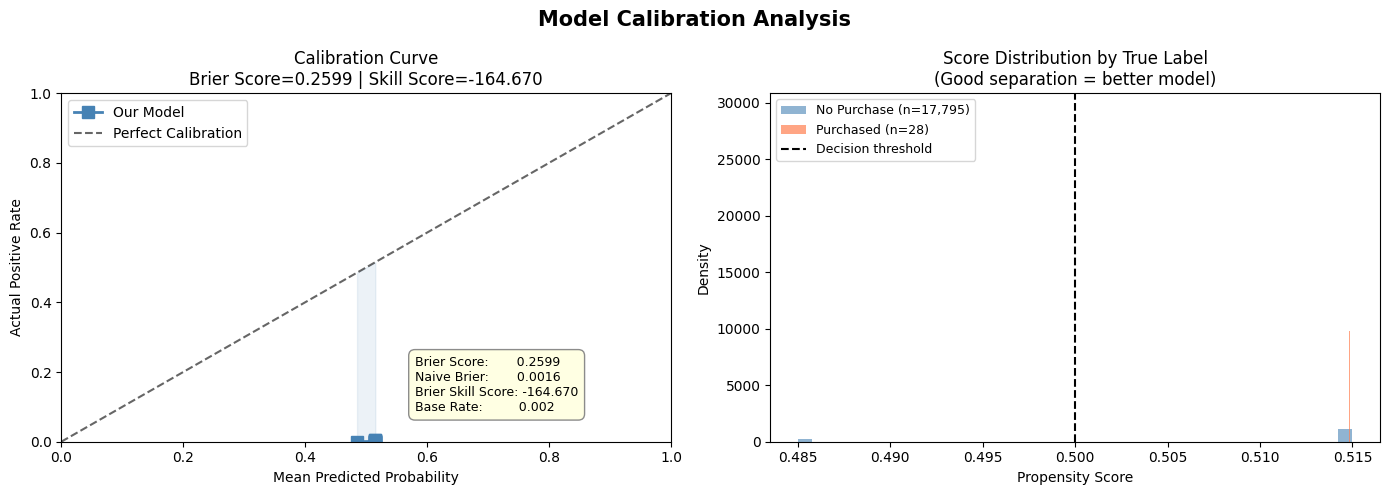

CALIBRATION SUMMARY:
  Brier Score:       0.2599  (lower is better; 0=perfect, 0.25=naive)
  Naive Brier:       0.0016  (always predict base rate)
  Brier Skill Score: -164.670  (% improvement over naive; higher=better)


In [175]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
# ════════════════════════════════════════════════════════════════
# BONUS CELL 7 — Model Calibration Check
# ════════════════════════════════════════════════════════════════
"""
Calibration answers: "When the model says P=0.8, do 80% of users
actually buy?" A WELL-CALIBRATED model is essential for:
  - Setting realistic expectations with clients
  - Using scores as actual probability estimates (not just rankings)
  - Downstream expected value calculations being meaningful

The Brier Score quantifies calibration quality (lower = better).
"""

# Compute calibration curve — bins predicted probabilities and
# compares to actual positive rate within each bin
fraction_of_positives, mean_predicted = calibration_curve(
    y_cls_test,
    propensity_scores_test,
    n_bins   = 10,
    strategy = 'quantile'   # equal-frequency bins (better for imbalanced data)
)

brier = brier_score_loss(y_cls_test, propensity_scores_test)
# Brier score for a naive model (always predict base rate)
base_rate = y_cls_test.mean()
brier_naive = brier_score_loss(y_cls_test, np.full_like(propensity_scores_test, base_rate))
brier_skill = 1 - (brier / brier_naive)  # Brier Skill Score (higher = better)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Calibration Analysis', fontsize=15, fontweight='bold')

# ── Calibration curve ─────────────────────────────────────────
axes[0].plot(mean_predicted, fraction_of_positives,
             's-', color='steelblue', linewidth=2, markersize=8, label='Our Model')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.5, alpha=0.6, label='Perfect Calibration')
axes[0].fill_between(mean_predicted,
                      fraction_of_positives,
                      mean_predicted,
                      alpha=0.1, color='steelblue')

axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Actual Positive Rate')
axes[0].set_title(f'Calibration Curve\nBrier Score={brier:.4f} | Skill Score={brier_skill:.3f}',
                   fontsize=12)
axes[0].legend()
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# Add text box with key stats
stats_text = (f"Brier Score:       {brier:.4f}\n"
              f"Naive Brier:       {brier_naive:.4f}\n"
              f"Brier Skill Score: {brier_skill:.3f}\n"
              f"Base Rate:         {base_rate:.3f}")
axes[0].text(0.58, 0.08, stats_text, transform=axes[0].transAxes,
             fontsize=9, verticalalignment='bottom',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                       edgecolor='gray', alpha=0.9))

# ── Score histogram by class ──────────────────────────────────
scores_pos = propensity_scores_test[y_cls_test == 1]
scores_neg = propensity_scores_test[y_cls_test == 0]
axes[1].hist(scores_neg, bins=40, alpha=0.6, color='steelblue',
             label=f'No Purchase (n={len(scores_neg):,})', density=True)
axes[1].hist(scores_pos, bins=40, alpha=0.7, color='coral',
             label=f'Purchased (n={len(scores_pos):,})',   density=True)
axes[1].axvline(0.5, color='black', linestyle='--', lw=1.5, label='Decision threshold')
axes[1].set_xlabel('Propensity Score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution by True Label\n(Good separation = better model)',
                   fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('calibration.png', dpi=150, bbox_inches='tight')
plt.show()

print("CALIBRATION SUMMARY:")
print(f"  Brier Score:       {brier:.4f}  (lower is better; 0=perfect, 0.25=naive)")
print(f"  Naive Brier:       {brier_naive:.4f}  (always predict base rate)")
print(f"  Brier Skill Score: {brier_skill:.3f}  (% improvement over naive; higher=better)")

